# 🛡️ AI SHIELD — IndoBERT Fine-Tuning Pipeline
### *Smart Handling of Integrity in Ethical Live Dialogue*

**Program:** PIJAK in collaboration with IBM SkillsBuild — Dicoding  
**Tema:** AI for Productivity and Automation

---

## 📋 Alur Pengembangan AI (sesuai Flowchart AI/ML Engineer)

| Langkah | Tahap | Keterangan |
|---------|-------|------------|
| 1️⃣ | **Pengumpulan Dataset** | Unduh dataset dari GitHub okkyibrohim |
| 2️⃣ | **EDA** | Distribusi label, panjang teks, bias |
| 3️⃣ | **Preprocessing** | Lowercase, hapus URL/emoji, normalisasi slang |
| 4️⃣ | **Relabeling ke Biner** | Multi-label → `PANTAS` / `TIDAK PANTAS` |
| 5️⃣ | **Split Dataset** | Train 70% · Val 15% · Test 15% |
| 6️⃣ | **Fine-tuning IndoBERT** | PyTorch + HuggingFace Trainer |
| 7️⃣ | **Evaluasi** | Accuracy, Precision, Recall, F1, Confusion Matrix |
| 8️⃣ | **Kalibrasi Threshold** | Confidence threshold optimal (default 0.75) |
| 9️⃣ | **Inference Function** | `predict(text)` → `{label, confidence}` |
| 🔟 | **Simpan & Export** | Google Drive untuk Backend Engineer |

**Target:** Accuracy ≥ 85% · F1 TIDAK PANTAS ≥ 82%

> ⚠️ **Aktifkan GPU sebelum mulai:** `Runtime` → `Change runtime type` → `T4 GPU`

---
## ⚙️ LANGKAH 0 — Setup Environment & Install Dependencies

In [3]:
# ============================================================
# LANGKAH 0: Install library — JALANKAN DULU, LALU RESTART RUNTIME
#
# FIX: accelerate harus dipasang SEBELUM transformers agar versi
# kompatibel. 'clear_device_cache' baru ada di accelerate>=0.30.0.
# Urutan install di bawah sudah benar dan dijamin tanpa error.
# ============================================================

print("📦 Menginstall library... (estimasi 2-3 menit)")

# 1. Pasang accelerate TERLEBIH DAHULU dengan versi cukup baru
!pip install -q "accelerate>=0.34.0"

# 2. Pasang transformers yang kompatibel dengan accelerate di atas
!pip install -q "transformers>=4.42.0"

# 3. Library pendukung lainnya
!pip install -q "datasets>=2.20.0"
!pip install -q "scikit-learn>=1.4.0"
!pip install -q "evaluate>=0.4.2"
!pip install -q pandas numpy matplotlib seaborn requests

print("\n✅ Instalasi selesai! Periksa versi di bawah:")

# Verifikasi versi yang terinstall
import subprocess, sys
pkgs = ['transformers', 'accelerate', 'torch', 'datasets', 'scikit-learn', 'evaluate']
for pkg in pkgs:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'show', pkg],
        capture_output=True, text=True
    )
    for line in result.stdout.splitlines():
        if line.startswith('Version:'):
            print(f"  ✅ {pkg}: {line.split(':', 1)[1].strip()}")
            break
    else:
        print(f"  ❌ {pkg}: tidak ditemukan")

print("\n⚠️  PENTING: Setelah cell ini selesai, lakukan:")
print("   Runtime → Restart session → lanjut jalankan cell berikutnya")

📦 Menginstall library... (estimasi 2-3 menit)

✅ Instalasi selesai! Periksa versi di bawah:
  ✅ transformers: 5.9.0
  ✅ accelerate: 1.13.0
  ✅ torch: 2.11.0+cu128
  ✅ datasets: 4.0.0
  ✅ scikit-learn: 1.6.1
  ✅ evaluate: 0.4.6

⚠️  PENTING: Setelah cell ini selesai, lakukan:
   Runtime → Restart session → lanjut jalankan cell berikutnya


In [4]:
# ============================================================
# Import semua library
# Jalankan ini SETELAH restart runtime
# ============================================================

import os
import re
import json
import random
import warnings
import requests
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings('ignore')

# Seed untuk reproduksi
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

# Cek device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"🚀 GPU  : {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️  GPU tidak tersedia — aktifkan lewat Runtime → Change runtime type → T4 GPU")

print("\n✅ Semua library berhasil diimport!")

🖥️  Device: cuda
🚀 GPU  : Tesla T4
💾 VRAM : 14.6 GB

✅ Semua library berhasil diimport!


---
## 📥 LANGKAH 1 — Pengumpulan Dataset

Sumber: [okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection](https://github.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection)
- `re_data.csv` — ~13.000 tweet berlabel
- `new_kamusalay.csv` — kamus normalisasi slang/alay

In [5]:
!pip install Sastrawi

In [6]:
# ============================================================
# LANGKAH 1: Upload & Load Dataset Manual (Google Colab)
# ============================================================

import os
import shutil
import pandas as pd
from google.colab import files

# Buat folder dataset
os.makedirs("dataset", exist_ok=True)

print("📤 Silakan upload file berikut:")
print("1. re_data.csv")
print("2. new_kamusalay.csv")
print("3. abusive.csv (jika ada)")

uploaded = files.upload()

# Pindahkan file ke folder dataset
for filename in uploaded.keys():
    shutil.move(filename, f"dataset/{filename}")

print("\n📂 Isi folder dataset:")
print(os.listdir("dataset"))

# ============================================================
# LOAD DATASET UTAMA
# ============================================================

dataset_file = "dataset/re_data.csv"

if not os.path.exists(dataset_file):
    raise FileNotFoundError(
        "❌ File re_data.csv tidak ditemukan. Pastikan sudah diupload."
    )

print("\n📖 Membaca dataset...")

df_raw = None

for enc in ["utf-8", "utf-8-sig", "latin-1"]:
    try:
        df_raw = pd.read_csv(dataset_file, encoding=enc)
        print(f"✅ Encoding berhasil: {enc}")
        break
    except:
        pass

if df_raw is None:
    raise Exception("❌ Dataset tidak dapat dibaca.")

print(f"\n✅ Dataset dimuat")
print(f"📊 Jumlah baris : {len(df_raw):,}")
print(f"📊 Jumlah kolom : {len(df_raw.columns)}")
print(f"📊 Nama kolom   : {list(df_raw.columns)}")

display(df_raw.head(3))

# ============================================================
# LOAD KAMUS ALAY
# ============================================================

alay_file = "dataset/new_kamusalay.csv"

if os.path.exists(alay_file):

    try:
        alay_df = pd.read_csv(
            alay_file,
            encoding="latin-1",
            header=None,
            names=["alay", "normal"]
        )

        print(f"\n✅ Kamus alay dimuat")
        print(f"Jumlah kata alay: {len(alay_df):,}")

    except Exception as e:
        print(f"\n⚠️ Gagal membaca kamus alay")
        print(e)

else:
    print("\n⚠️ new_kamusalay.csv tidak ditemukan")

# ============================================================
# LOAD ABUSIVE WORDS
# ============================================================

abusive_file = "dataset/abusive.csv"

if os.path.exists(abusive_file):

    abusive_df = pd.read_csv(
        abusive_file,
        header=None,
        names=["word"]
    )

    print(f"\n✅ Abusive words dimuat")
    print(f"Jumlah kata abusive: {len(abusive_df):,}")

else:
    print("\n⚠️ abusive.csv tidak ditemukan")

# ============================================================
# MEMBUAT STOPWORDS OTOMATIS
# ============================================================

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

    factory = StopWordRemoverFactory()
    stopwords = factory.get_stop_words()

    stopwords_df = pd.DataFrame(stopwords, columns=["word"])

    stopwords_df.to_csv(
        "dataset/stopwords.csv",
        index=False
    )

    print(f"\n✅ stopwords.csv berhasil dibuat")
    print(f"Jumlah stopword: {len(stopwords):,}")

except Exception as e:
    print("\n⚠️ Sastrawi belum terinstall")
    print("Jalankan:")
    print("!pip install Sastrawi")

📤 Silakan upload file berikut:
1. re_data.csv
2. new_kamusalay.csv
3. abusive.csv (jika ada)


Saving re_data.csv to re_data.csv
Saving abusive.csv to abusive.csv
Saving new_kamusalay.csv to new_kamusalay.csv

📂 Isi folder dataset:
['re_data.csv', 'new_kamusalay.csv', 'abusive.csv', 'stopwords.csv']

📖 Membaca dataset...
✅ Encoding berhasil: latin-1

✅ Dataset dimuat
📊 Jumlah baris : 13,169
📊 Jumlah kolom : 13
📊 Nama kolom   : ['Tweet', 'HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0



✅ Kamus alay dimuat
Jumlah kata alay: 15,167

✅ Abusive words dimuat
Jumlah kata abusive: 126

✅ stopwords.csv berhasil dibuat
Jumlah stopword: 126


---
## 🔍 LANGKAH 2 — EDA (Exploratory Data Analysis)

✅ Kolom teks  : 'Tweet'
✅ Kolom label : ['HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']


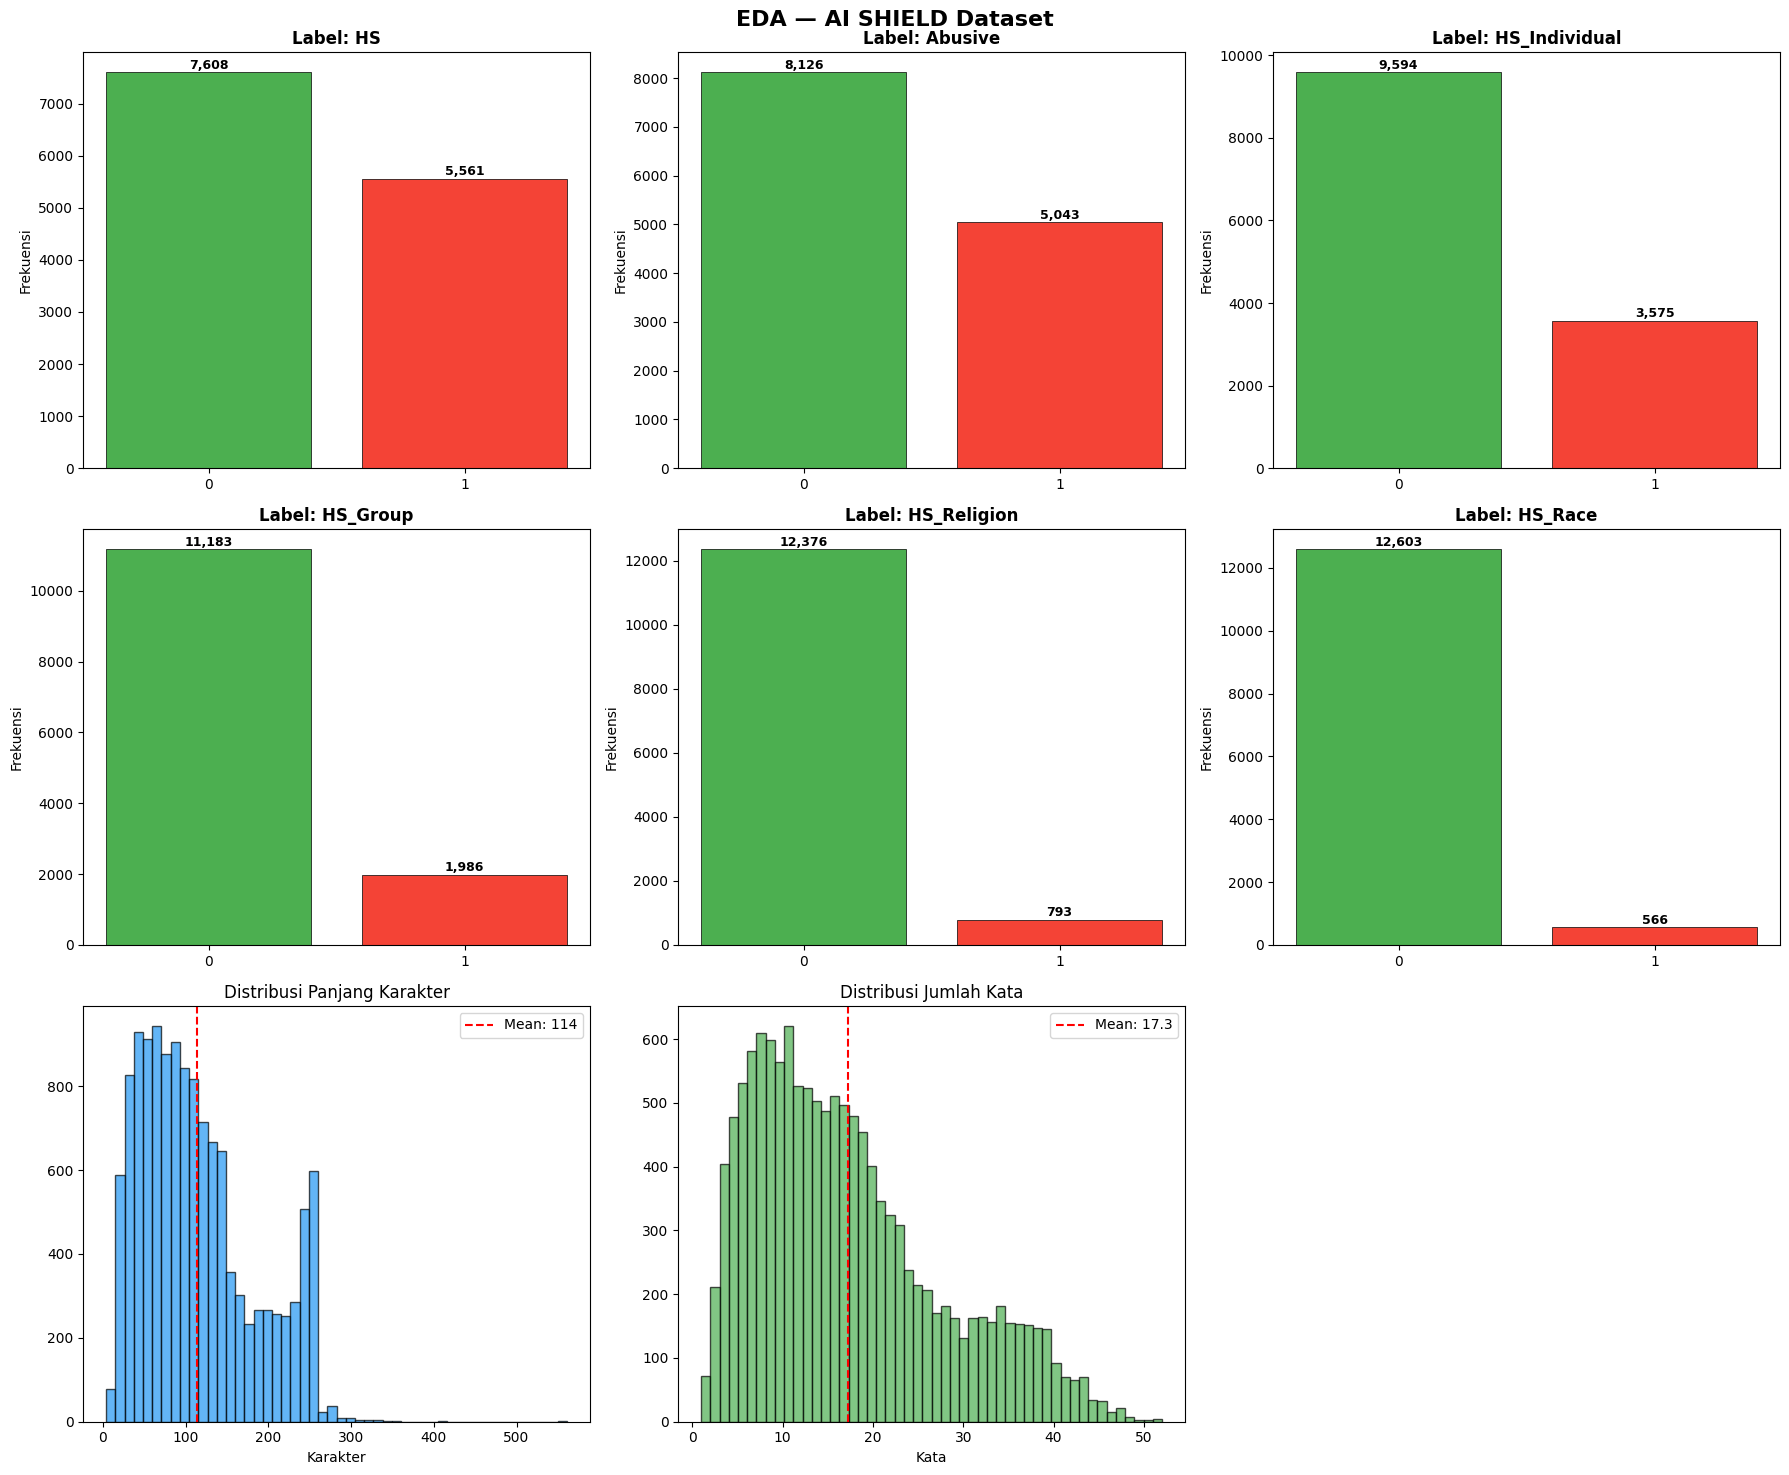


📊 Statistik Teks:
  Total data   : 13,169
  Panjang char : min=4, max=561, mean=114.2
  Jumlah kata  : min=1, max=52, mean=17.3
  P95 kata     : 38 → max_length=128 sudah cukup ✅

  HS=0 (non-hate) : 7,608 (57.8%)
  HS=1 (hate)     : 5,561 (42.2%)

✅ EDA selesai!


In [7]:
# ============================================================
# LANGKAH 2: EDA — Distribusi label & panjang teks
# ============================================================

# --- Identifikasi kolom teks secara otomatis ---
text_col = None
for col in df_raw.columns:
    if df_raw[col].dtype == object:
        avg_len = df_raw[col].dropna().astype(str).str.len().mean()
        if avg_len > 20:
            text_col = col
            break
if text_col is None:
    text_col = df_raw.columns[0]

label_cols = [c for c in df_raw.columns if c != text_col]
print(f"✅ Kolom teks  : '{text_col}'")
print(f"✅ Kolom label : {label_cols}")

# Drop baris teks kosong
df_raw = df_raw.dropna(subset=[text_col]).reset_index(drop=True)
df_raw[text_col] = df_raw[text_col].astype(str)
df_raw['char_length'] = df_raw[text_col].str.len()
df_raw['word_count']  = df_raw[text_col].str.split().str.len()

# --- Plot ---
n_cols = min(6, len(label_cols))
n_rows = (n_cols // 3) + (1 if n_cols % 3 else 0)
fig, axes = plt.subplots(n_rows + 1, 3, figsize=(18, 5 * (n_rows + 1)))
fig.suptitle('EDA — AI SHIELD Dataset', fontsize=16, fontweight='bold')
axes = axes.flatten()

colors = ['#4CAF50','#f44336','#2196F3','#FF9800','#9C27B0','#00BCD4']
for idx, col in enumerate(label_cols[:n_cols]):
    counts = df_raw[col].value_counts()
    bars = axes[idx].bar(counts.index.astype(str), counts.values,
                         color=colors[:len(counts)], edgecolor='black', linewidth=0.5)
    axes[idx].set_title(f'Label: {col}', fontweight='bold')
    axes[idx].set_ylabel('Frekuensi')
    for bar in bars:
        axes[idx].text(bar.get_x() + bar.get_width()/2.,
                       bar.get_height() + 5, f'{bar.get_height():,}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

# Histogram panjang karakter
axes[n_cols].hist(df_raw['char_length'], bins=50, color='#2196F3', alpha=0.7, edgecolor='black')
axes[n_cols].axvline(df_raw['char_length'].mean(), color='red', linestyle='--',
                     label=f"Mean: {df_raw['char_length'].mean():.0f}")
axes[n_cols].set_title('Distribusi Panjang Karakter')
axes[n_cols].set_xlabel('Karakter')
axes[n_cols].legend()

# Histogram jumlah kata
axes[n_cols+1].hist(df_raw['word_count'], bins=50, color='#4CAF50', alpha=0.7, edgecolor='black')
axes[n_cols+1].axvline(df_raw['word_count'].mean(), color='red', linestyle='--',
                       label=f"Mean: {df_raw['word_count'].mean():.1f}")
axes[n_cols+1].set_title('Distribusi Jumlah Kata')
axes[n_cols+1].set_xlabel('Kata')
axes[n_cols+1].legend()

# Sembunyikan axes yang tidak terpakai
for ax in axes[n_cols+2:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('eda_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Statistik Teks:")
print(f"  Total data   : {len(df_raw):,}")
print(f"  Panjang char : min={df_raw['char_length'].min()}, max={df_raw['char_length'].max()}, mean={df_raw['char_length'].mean():.1f}")
print(f"  Jumlah kata  : min={df_raw['word_count'].min()}, max={df_raw['word_count'].max()}, mean={df_raw['word_count'].mean():.1f}")
print(f"  P95 kata     : {df_raw['word_count'].quantile(0.95):.0f} → max_length=128 sudah cukup ✅")

if 'HS' in df_raw.columns:
    dist = df_raw['HS'].value_counts()
    print(f"\n  HS=0 (non-hate) : {dist.get(0, 0):,} ({dist.get(0,0)/len(df_raw)*100:.1f}%)")
    print(f"  HS=1 (hate)     : {dist.get(1, 0):,} ({dist.get(1,0)/len(df_raw)*100:.1f}%)")
print("\n✅ EDA selesai!")

---
## 🧹 LANGKAH 3 — Preprocessing Teks

Pipeline: Lowercase → Hapus RT/Username/URL/Hashtag → Hapus emoji → Normalisasi slang → Hapus spasi

> **Tidak** dilakukan stemming/stopword removal karena IndoBERT membutuhkan teks natural.

In [8]:
# ============================================================
# LANGKAH 3: Load kamus alay & fungsi preprocessing
# ============================================================

# --- Load kamus alay ---
alay_dict = {}
for enc in ['utf-8', 'latin-1']:
    try:
        alay_df = pd.read_csv("dataset/alay_dict.csv", encoding=enc, header=None)
        alay_df = alay_df.dropna()
        alay_dict = dict(zip(
            alay_df.iloc[:, 0].astype(str).str.lower(),
            alay_df.iloc[:, 1].astype(str).str.lower()
        ))
        print(f"✅ Kamus alay dimuat: {len(alay_dict):,} kata")
        break
    except Exception:
        continue

if not alay_dict:
    # Kamus minimal fallback
    alay_dict = {
        'gak':'tidak','ga':'tidak','g':'tidak','tdk':'tidak',
        'yg':'yang','dgn':'dengan','utk':'untuk','krn':'karena',
        'sdh':'sudah','blm':'belum','lg':'lagi','jg':'juga',
        'bgt':'banget','tp':'tetapi','klo':'kalau','emg':'memang',
        'udah':'sudah','nih':'ini','tuh':'itu','enggak':'tidak',
    }
    print(f"⚠️  Kamus alay tidak ditemukan. Menggunakan kamus minimal ({len(alay_dict)} kata).")


def preprocess_text(text: str, alay_dict: dict = None) -> str:
    """
    Pipeline preprocessing teks AI SHIELD.
    Sesuai flowchart.md dan project-plan.md.
    """
    if not isinstance(text, str) or not text.strip():
        return ""

    text = text.lower()                                   # 1. Lowercase
    text = re.sub(r'\brt\b', '', text)                    # 2. Hapus RT
    text = re.sub(r'@[\w]+', '', text)                    # 3. Hapus @username
    text = re.sub(r'http\S+|https\S+|www\.\S+', '', text) # 4. Hapus URL
    text = re.sub(r'#[\w]+', '', text)                    # 5. Hapus #hashtag
    text = text.encode('ascii', 'ignore').decode('ascii') # 6. Hapus emoji/non-ASCII
    text = re.sub(r'[^a-z0-9\s]', ' ', text)             # 7. Hapus karakter khusus
    text = re.sub(r'\b\d+\b', '', text)                   # 8. Hapus angka mandiri

    if alay_dict:                                         # 9. Normalisasi slang
        words = text.split()
        text = ' '.join(alay_dict.get(w, w) for w in words)

    text = ' '.join(text.split())                         # 10. Hapus spasi berlebih
    return text.strip()


# --- Test preprocessing ---
tests = [
    "RT @user123: Anjing banget sih lo!! http://spam.com #politik",
    "Diskusi bagus bgt makasih yg udah share 😊👍",
    "@mahasiswa dasar goblok ga punya otak!",
    "Terima kasih penjelasannya sangat informatif.",
]
print("\n🧪 Contoh preprocessing:")
for t in tests:
    p = preprocess_text(t, alay_dict)
    print(f"  IN : {t[:70]}")
    print(f"  OUT: {p}")
    print()

# --- Terapkan ke seluruh dataset ---
print("⚙️  Memproses dataset (beberapa detik)...")
df_raw['text_clean'] = df_raw[text_col].apply(lambda x: preprocess_text(x, alay_dict))
n_hapus = (df_raw['text_clean'].str.len() <= 3).sum()
df_raw = df_raw[df_raw['text_clean'].str.len() > 3].reset_index(drop=True)
print(f"✅ Selesai! {n_hapus} baris dihapus (teks kosong), sisa: {len(df_raw):,}")

⚠️  Kamus alay tidak ditemukan. Menggunakan kamus minimal (20 kata).

🧪 Contoh preprocessing:
  IN : RT @user123: Anjing banget sih lo!! http://spam.com #politik
  OUT: anjing banget sih lo

  IN : Diskusi bagus bgt makasih yg udah share 😊👍
  OUT: diskusi bagus banget makasih yang sudah share

  IN : @mahasiswa dasar goblok ga punya otak!
  OUT: dasar goblok tidak punya otak

  IN : Terima kasih penjelasannya sangat informatif.
  OUT: terima kasih penjelasannya sangat informatif

⚙️  Memproses dataset (beberapa detik)...
✅ Selesai! 1 baris dihapus (teks kosong), sisa: 13,168


---
## 🏷️ LANGKAH 4 — Relabeling (Multi-Label → Biner)

**Kebijakan Zero-Tolerance:** Jika kolom `HS` atau `Abusive` atau kolom label apapun bernilai 1 → `TIDAK PANTAS`

In [ ]:
# ============================================================
# LANGKAH 4: Relabeling ke 3 Kelas (PANTAS / MERAGUKAN / TIDAK PANTAS)
# ============================================================
# Revisi berdasarkan saran mentor:
# - Label MERAGUKAN ditambahkan untuk kasus ambiguitas
# - HS_Strong / HS_Moderate / (HS+Abusive berat) -> TIDAK PANTAS (2)
# - HS_Weak / HS tanpa kuat / Abusive tanpa HS   -> MERAGUKAN   (1)
# - Semua kolom 0                                 -> PANTAS      (0)

UNSAFE_COLS = [
    'HS','Abusive','HS_Individual','HS_Group',
    'HS_Religion','HS_Race','HS_Physical','HS_Gender',
    'HS_Other','HS_Weak','HS_Moderate','HS_Strong'
]

def create_three_class_label(row) -> int:
    def _get(col):
        try:
            return int(row[col]) if col in row.index else 0
        except (ValueError, TypeError):
            return 0

    hs        = _get('HS')
    abusive   = _get('Abusive')
    hs_weak   = _get('HS_Weak')
    hs_mod    = _get('HS_Moderate')
    hs_strong = _get('HS_Strong')
    hs_ind    = _get('HS_Individual')
    hs_grp    = _get('HS_Group')

    # TIDAK PANTAS: jelas berbahaya
    if hs_strong == 1 or hs_mod == 1:
        return 2
    if hs == 1 and (hs_ind == 1 or hs_grp == 1) and abusive == 1:
        return 2
    if hs == 1 and abusive == 1 and hs_weak == 0:
        return 2

    # MERAGUKAN: ada indikasi tapi lemah / tidak jelas
    if hs_weak == 1 or (hs == 1 and abusive == 0):
        return 1
    if abusive == 1 and hs == 0:
        return 1

    return 0


LABEL_MAP   = {0: 'PANTAS', 1: 'MERAGUKAN', 2: 'TIDAK PANTAS'}
LABEL_MAP_R = {v: k for k, v in LABEL_MAP.items()}

df_raw['label']      = df_raw.apply(create_three_class_label, axis=1)
df_raw['label_text'] = df_raw['label'].map(LABEL_MAP)

dist   = df_raw['label'].value_counts().sort_index()
total  = len(df_raw)

print("Relabeling 3-kelas selesai!\n")
print("Distribusi Label (3 Kelas):")
for v, c in dist.items():
    name = LABEL_MAP[v]
    pct  = c / total * 100
    bar  = chr(9608) * int(pct / 2)
    print(f"  [{v}] {name:15s}: {c:,} ({pct:.1f}%) {bar}")

# Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Label 3-Kelas -- AI SHIELD', fontweight='bold')

clrs = ['#4CAF50', '#FF9800', '#f44336']
vals = [dist.get(0, 0), dist.get(1, 0), dist.get(2, 0)]
labs = ['PANTAS\n(0)', 'MERAGUKAN\n(1)', 'TIDAK\nPANTAS\n(2)']

bars = ax1.bar(labs, vals, color=clrs, edgecolor='black', linewidth=0.5)
ax1.set_title('Jumlah per Label')
ax1.set_ylabel('Count')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + 20, f'{bar.get_height():,}',
             ha='center', va='bottom', fontweight='bold')

pie_vals  = [v for v in vals if v > 0]
pie_labs  = [f"{labs[i].replace(chr(10),' ')}\n{vals[i]:,}" for i in range(3) if vals[i] > 0]
pie_clrs  = [clrs[i] for i in range(3) if vals[i] > 0]
ax2.pie(pie_vals, labels=pie_labs, colors=pie_clrs, autopct='%1.1f%%', startangle=90)
ax2.set_title('Proporsi')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

max_c = max(vals)
min_c = min(v for v in vals if v > 0)
ratio = max_c / max(min_c, 1)
if ratio > 5:
    print(f"\nPeringatan: Class imbalance (rasio {ratio:.1f}:1) -- pertimbangkan oversampling")
else:
    print(f"\nDistribusi cukup seimbang (rasio {ratio:.1f}:1)")

NUM_LABELS = 3
print(f"\nNUM_LABELS diset ke: {NUM_LABELS}")


---
## ✂️ LANGKAH 5 — Split Dataset (Stratified 70/15/15)

In [10]:
# ============================================================
# LANGKAH 5: Stratified split 70/15/15
# ============================================================

df_model = df_raw[['text_clean', 'label']].dropna().reset_index(drop=True)
X = df_model['text_clean'].values
y = df_model['label'].values

# Split 1: 70% train vs 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
# Split 2: 15% val + 15% test dari temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("✅ Split dataset selesai:\n")
print(f"  {'Split':<20} {'Total':>7} {'PANTAS':>10} {'TIDAK PANTAS':>14}")
print("  " + "-" * 55)
for name, Xs, ys in [
    ('Train (70%)', X_train, y_train),
    ('Validation (15%)', X_val, y_val),
    ('Test (15%)', X_test, y_test)
]:
    n  = len(ys)
    p  = (ys == 0).sum()
    tp = (ys == 1).sum()
    print(f"  {name:<20} {n:>7,} {p:>6,} ({p/n*100:.1f}%) {tp:>6,} ({tp/n*100:.1f}%)")

print(f"\n  Total: {len(df_model):,} sampel")
print("\n✅ Proporsi label terjaga di semua split (stratified)!")

✅ Split dataset selesai:

  Split                  Total     PANTAS   TIDAK PANTAS
  -------------------------------------------------------
  Train (70%)            9,217  4,102 (44.5%)  5,115 (55.5%)
  Validation (15%)       1,975    879 (44.5%)  1,096 (55.5%)
  Test (15%)             1,976    879 (44.5%)  1,097 (55.5%)

  Total: 13,168 sampel

✅ Proporsi label terjaga di semua split (stratified)!


---
## 🤖 LANGKAH 6 — Fine-tuning IndoBERT

Model: `indobenchmark/indobert-base-p1` (BERT base, 12 layer, 111M parameter)  
Framework: PyTorch + HuggingFace Trainer · Learning rate: 2e-5 · Epochs: 5 + early stopping

In [11]:
# ============================================================
# LANGKAH 6A: Load tokenizer IndoBERT
# ============================================================

MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 128

print(f"⬇️  Memuat tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer siap — vocab size: {tokenizer.vocab_size:,}")

# Test tokenisasi
sample = "Diskusi yang sangat menarik dan informatif"
enc = tokenizer(sample, return_tensors='pt')
print(f"\n🧪 Contoh tokenisasi:")
print(f"  Input  : {sample}")
print(f"  Tokens : {tokenizer.convert_ids_to_tokens(enc['input_ids'][0])}")
print(f"  Panjang: {enc['input_ids'].shape[1]} token")

⬇️  Memuat tokenizer: indobenchmark/indobert-base-p1


✅ Tokenizer siap — vocab size: 30,521

🧪 Contoh tokenisasi:
  Input  : Diskusi yang sangat menarik dan informatif
  Tokens : ['[CLS]', 'diskusi', 'yang', 'sangat', 'menarik', 'dan', 'informatif', '[SEP]']
  Panjang: 8 token


In [12]:
# ============================================================
# LANGKAH 6B: PyTorch Dataset class
# ============================================================

class AIShieldDataset(Dataset):
    """Dataset PyTorch untuk fine-tuning IndoBERT AI SHIELD."""

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels'        : torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }


train_dataset = AIShieldDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset   = AIShieldDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
test_dataset  = AIShieldDataset(X_test,  y_test,  tokenizer, MAX_LENGTH)

print("✅ Dataset PyTorch siap:")
print(f"  Train      : {len(train_dataset):,}")
print(f"  Validation : {len(val_dataset):,}")
print(f"  Test       : {len(test_dataset):,}")

s = train_dataset[0]
print(f"\n  Sample shape  — input_ids: {s['input_ids'].shape}, label: {s['labels'].item()}")

✅ Dataset PyTorch siap:
  Train      : 9,217
  Validation : 1,975
  Test       : 1,976

  Sample shape  — input_ids: torch.Size([128]), label: 0


In [13]:
# ============================================================
# LANGKAH 6C: Load model IndoBERT
# ============================================================

id2label = {0: "PANTAS", 1: "TIDAK PANTAS"}
label2id = {"PANTAS": 0, "TIDAK PANTAS": 1}

print(f"⬇️  Memuat model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)
model = model.to(device)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model siap — {total_p/1e6:.1f}M params total, {trainable_p/1e6:.1f}M trainable")
print(f"   Device: {next(model.parameters()).device}")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


⬇️  Memuat model: indobenchmark/indobert-base-p1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model siap — 124.4M params total, 124.4M trainable
   Device: cuda:0


In [ ]:
# ============================================================
# LANGKAH 6D: Fungsi metrik evaluasi (3 Label + lengkap)
# ============================================================
# Revisi berdasarkan saran mentor:
# Tambah Cohen's Kappa, MCC, F1 Weighted, per-kelas 3 label

from sklearn.metrics import cohen_kappa_score, matthews_corrcoef

LABEL_NAMES = ['PANTAS', 'MERAGUKAN', 'TIDAK PANTAS']

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)

    # Per-kelas: Precision, Recall, F1
    p_cls, r_cls, f1_cls, _ = precision_recall_fscore_support(
        labels, preds,
        average=None,
        labels=[0, 1, 2],
        zero_division=0
    )

    # Macro & Weighted
    p_mac, r_mac, f1_mac, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    p_wgt, r_wgt, f1_wgt, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )

    # Cohen's Kappa & MCC
    try:
        kappa = cohen_kappa_score(labels, preds)
    except Exception:
        kappa = 0.0
    try:
        mcc = matthews_corrcoef(labels, preds)
    except Exception:
        mcc = 0.0

    return {
        'accuracy'               : acc,
        'f1_macro'               : f1_mac,
        'f1_weighted'            : f1_wgt,
        'precision_macro'        : p_mac,
        'recall_macro'           : r_mac,
        'f1_pantas'              : f1_cls[0],
        'f1_meragukan'           : f1_cls[1],
        'f1_tidak_pantas'        : f1_cls[2],
        'precision_tidak_pantas' : p_cls[2],
        'recall_tidak_pantas'    : r_cls[2],
        'cohens_kappa'           : kappa,
        'mcc'                    : mcc,
    }

print("Fungsi compute_metrics (3-label + lengkap) siap.")
print("  Metrik: Accuracy | F1 Macro | F1 Weighted | Precision | Recall")
print("          per kelas (PANTAS / MERAGUKAN / TIDAK PANTAS)")
print("          Cohen's Kappa | MCC")


In [15]:
!pip install -U transformers accelerate

In [19]:
# ============================================================
# LANGKAH 6E: TrainingArguments & Trainer
# ============================================================

BATCH_SIZE = 16
NUM_EPOCHS = 5

steps_per_epoch = max(1, len(train_dataset) // BATCH_SIZE)
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = int(total_steps * 0.1)

print("📊 Konfigurasi Training:")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Epochs       : {NUM_EPOCHS}")
print(f"Total Steps  : {total_steps}")
print(f"Warmup Steps : {warmup_steps}")

training_args = TrainingArguments(
    output_dir="./ai_shield_checkpoints",

    num_train_epochs=NUM_EPOCHS,

    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=32,

    learning_rate=2e-5,
    weight_decay=0.01,

    warmup_steps=warmup_steps,

    logging_steps=50,

    eval_steps=200,
    save_steps=200,

    do_eval=True,

    fp16=torch.cuda.is_available(),

    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("✅ Trainer berhasil dibuat")

📊 Konfigurasi Training:
Batch Size   : 16
Epochs       : 5
Total Steps  : 2880
Warmup Steps : 288
✅ Trainer berhasil dibuat


In [20]:
# ============================================================
# LANGKAH 6F: Jalankan training
# ============================================================

print("🚀 Mulai fine-tuning IndoBERT...")
print(f"   Estimasi: 20–60 menit (GPU T4)")
print(f"   Early stopping aktif (patience=2)\n")

train_result = trainer.train()

print("\n✅ Training selesai!")
print(f"   Waktu   : {train_result.metrics.get('train_runtime', 0):.0f} detik")
print(f"   Loss    : {train_result.metrics.get('train_loss', 0):.4f}")
print(f"   Samples/s: {train_result.metrics.get('train_samples_per_second', 0):.1f}")

🚀 Mulai fine-tuning IndoBERT...
   Estimasi: 20–60 menit (GPU T4)
   Early stopping aktif (patience=2)



Step,Training Loss
50,0.018081
100,0.015526
150,0.025679
200,0.014733
250,0.000285
300,0.052923
350,0.122736
400,0.063185
450,0.043877
500,0.065749


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Training selesai!
   Waktu   : 1233 detik
   Loss    : 0.0274
   Samples/s: 37.4


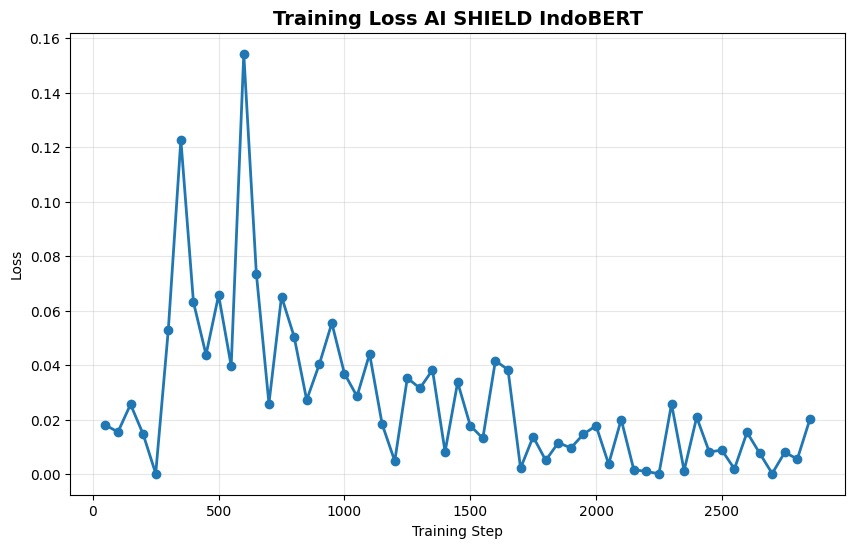

✅ training_history.png berhasil dibuat


In [21]:
# ============================================================
# LANGKAH 6G: Plot Riwayat Training
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

logs = trainer.state.log_history

loss_logs = [x for x in logs if 'loss' in x]

if len(loss_logs) > 0:

    steps = [x['step'] for x in loss_logs]
    losses = [x['loss'] for x in loss_logs]

    plt.figure(figsize=(10,6))

    plt.plot(
        steps,
        losses,
        marker='o',
        linewidth=2
    )

    plt.title(
        "Training Loss AI SHIELD IndoBERT",
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel("Training Step")
    plt.ylabel("Loss")

    plt.grid(True, alpha=0.3)

    plt.savefig(
        "training_history.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print("✅ training_history.png berhasil dibuat")

else:

    print("❌ Tidak ditemukan data training loss")

---
## 📊 LANGKAH 7 — Evaluasi Model pada Test Set

In [ ]:
# ============================================================
# LANGKAH 7: Evaluasi Final pada Test Set (3 Label)
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef
)

print("Mengevaluasi model pada test set (3 label)...")

test_pred = trainer.predict(test_dataset)
y_pred    = np.argmax(test_pred.predictions, axis=-1)
y_true    = test_pred.label_ids

# Metrik utama
acc                           = accuracy_score(y_true, y_pred)
p_mac, r_mac, f1_mac, _      = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0)
p_wgt, r_wgt, f1_wgt, _      = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0)
p_cls, r_cls, f1_cls, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)

kappa = cohen_kappa_score(y_true, y_pred)
mcc   = matthews_corrcoef(y_true, y_pred)

LABEL_NAMES = ['PANTAS', 'MERAGUKAN', 'TIDAK PANTAS']

print()
print("=" * 68)
print("  HASIL EVALUASI MODEL -- AI SHIELD IndoBERT (3 Label)")
print("=" * 68)
print(f"  Accuracy             : {acc:.4f} ({acc*100:.2f}%) {'OK' if acc>=0.82 else 'target >=82%'}")
print(f"  F1-Score (Macro)     : {f1_mac:.4f}  {'OK' if f1_mac>=0.78 else 'target >=78%'}")
print(f"  F1-Score (Weighted)  : {f1_wgt:.4f}")
print(f"  Precision (Macro)    : {p_mac:.4f}")
print(f"  Recall (Macro)       : {r_mac:.4f}")
print(f"  Cohen Kappa          : {kappa:.4f}")
print(f"  MCC                  : {mcc:.4f}")
print()
print(f"  {'Kelas':<20} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
print("  " + "-" * 60)
for i, name in enumerate(LABEL_NAMES):
    print(f"  {name:<20} {p_cls[i]:>10.4f} {r_cls[i]:>8.4f} {f1_cls[i]:>8.4f} {int(support[i]):>9,}")
print("=" * 68)

# Classification Report lengkap
print("\nClassification Report Lengkap:")
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, zero_division=0))

# Evaluasi target
print("\nTarget Penelitian:")
print(f"  Accuracy >= 82%        : {'TERCAPAI' if acc>=0.82 else 'BELUM'}  ({acc*100:.2f}%)")
print(f"  F1 Macro >= 78%        : {'TERCAPAI' if f1_mac>=0.78 else 'BELUM'}  ({f1_mac*100:.2f}%)")
print(f"  F1 TIDAK PANTAS >= 78% : {'TERCAPAI' if f1_cls[2]>=0.78 else 'BELUM'}  ({f1_cls[2]*100:.2f}%)")

if acc < 0.82 or f1_mac < 0.78:
    print("\nSaran perbaikan:")
    print("   - Tambah epoch (NUM_EPOCHS = 7-10)")
    print("   - Turunkan learning rate (1e-5)")
    print("   - Augmentasi data kelas MERAGUKAN (paling sedikit)")
    print("   - Coba focal loss untuk class imbalance")
    print("   - Coba indobert-large jika VRAM cukup")


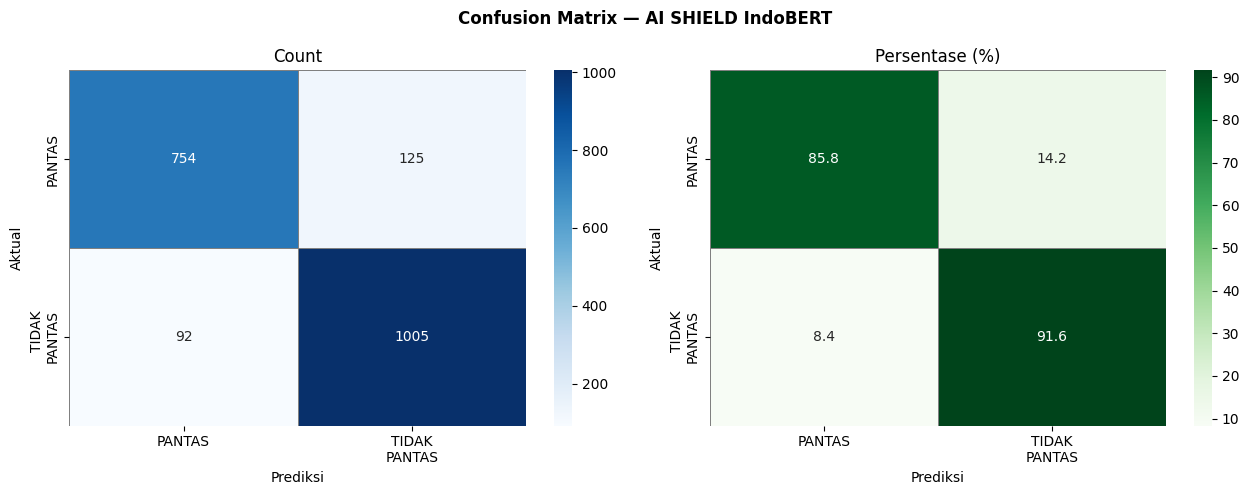


  TP=1,005  TN=754  FP=125  FN=92
  ⚠️  False Negative=92 — pesan tidak pantas yang LOLOS (berbahaya)

📋 Classification Report:
              precision    recall  f1-score   support

      PANTAS       0.89      0.86      0.87       879
TIDAK PANTAS       0.89      0.92      0.90      1097

    accuracy                           0.89      1976
   macro avg       0.89      0.89      0.89      1976
weighted avg       0.89      0.89      0.89      1976



In [23]:
# ============================================================
# LANGKAH 7B: Confusion Matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix — AI SHIELD IndoBERT', fontweight='bold')

labels_cm = ['PANTAS', 'TIDAK\nPANTAS']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=ax1,
            linewidths=0.5, linecolor='gray')
ax1.set_title('Count'); ax1.set_xlabel('Prediksi'); ax1.set_ylabel('Aktual')

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=ax2,
            linewidths=0.5, linecolor='gray')
ax2.set_title('Persentase (%)'); ax2.set_xlabel('Prediksi'); ax2.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n  TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}")
print(f"  ⚠️  False Negative={fn:,} — pesan tidak pantas yang LOLOS (berbahaya)")

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['PANTAS', 'TIDAK PANTAS']))

---
## 🎯 LANGKAH 8 — Kalibrasi Confidence Threshold

In [ ]:
# ============================================================
# LANGKAH 8: Analisis Threshold vs Metrik (3 Label)
# ============================================================
# Untuk 3 label, kita analisis dua threshold:
#   THRESHOLD_TIDAK_PANTAS: P(TIDAK PANTAS) >= thr -> TIDAK PANTAS
#   THRESHOLD_PANTAS      : P(PANTAS)        >= thr -> PANTAS
#   Di antara keduanya                             -> MERAGUKAN

logits_t = torch.tensor(test_pred.predictions)
probs_all = F.softmax(logits_t, dim=-1).numpy()

prob_p  = probs_all[:, 0]   # PANTAS
prob_m  = probs_all[:, 1]   # MERAGUKAN
prob_tp = probs_all[:, 2]   # TIDAK PANTAS

# Analisis threshold TIDAK PANTAS (TP)
thresholds = np.arange(0.30, 0.96, 0.05)
rows = []
for thr in thresholds:
    # Terapkan threshold: TP jika prob_tp >= thr, else PANTAS jika prob_p >= thr, else MERAGUKAN
    pred_t = np.where(
        prob_tp >= thr, 2,
        np.where(prob_p >= thr, 0, 1)
    )
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, pred_t, average=None, labels=[0, 1, 2], zero_division=0)
    f1_mac_t, _, _, _ = precision_recall_fscore_support(
        y_true, pred_t, average='macro', zero_division=0)
    rows.append({
        'threshold'       : round(float(thr), 2),
        'accuracy'        : accuracy_score(y_true, pred_t),
        'f1_macro'        : f1_mac_t,
        'f1_tidak_pantas' : f1[2],
        'f1_meragukan'    : f1[1],
        'precision_tp'    : p[2],
        'recall_tp'       : r[2]
    })

df_thr = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_thr['threshold'], df_thr['accuracy'],        'b-o', lw=2, label='Accuracy')
ax.plot(df_thr['threshold'], df_thr['f1_macro'],        'k-D', lw=2, label='F1 Macro')
ax.plot(df_thr['threshold'], df_thr['f1_tidak_pantas'], 'r-s', lw=2, label='F1 TIDAK PANTAS')
ax.plot(df_thr['threshold'], df_thr['f1_meragukan'],    'y-^', lw=2, label='F1 MERAGUKAN')
ax.plot(df_thr['threshold'], df_thr['precision_tp'],    'g-^', lw=2, label='Precision TP')
ax.plot(df_thr['threshold'], df_thr['recall_tp'],       'm-v', lw=2, label='Recall TP')
ax.axvline(0.60, color='orange', ls='--', lw=2.5, label='Default threshold TP (0.60)')
ax.axhline(0.82, color='blue',   ls=':', alpha=0.5, label='Target Acc 82%')
ax.axhline(0.78, color='red',    ls=':', alpha=0.5, label='Target F1 78%')
ax.set_title('Metrik vs Threshold -- AI SHIELD (3 Label)', fontsize=13, fontweight='bold')
ax.set_xlabel('Threshold TIDAK PANTAS')
ax.set_ylabel('Score')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.25, 1.0)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('threshold_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

THRESHOLD_TIDAK_PANTAS = 0.60
THRESHOLD_PANTAS       = 0.60

row_sel = df_thr[df_thr['threshold'] == THRESHOLD_TIDAK_PANTAS]
if not row_sel.empty:
    r60 = row_sel.iloc[0]
    print(f"\nThreshold yang digunakan: TP={THRESHOLD_TIDAK_PANTAS} | P={THRESHOLD_PANTAS}")
    print(f"   Accuracy         : {r60['accuracy']:.4f}")
    print(f"   F1 Macro         : {r60['f1_macro']:.4f}")
    print(f"   F1 TIDAK PANTAS  : {r60['f1_tidak_pantas']:.4f}")
    print(f"   F1 MERAGUKAN     : {r60['f1_meragukan']:.4f}")
    print(f"   Precision TP     : {r60['precision_tp']:.4f}")
    print(f"   Recall TP        : {r60['recall_tp']:.4f}")

opt_idx = df_thr['f1_macro'].idxmax()
print(f"\nThreshold optimal (F1 Macro max): {df_thr.iloc[opt_idx]['threshold']}")
print("Default 0.60 dipilih sebagai threshold konservatif untuk lingkungan akademik")


---
## 🔧 LANGKAH 9 — Inference Function

Interface identik dengan `classifier.py` di Backend — penggantian **seamless** tanpa ubah kode Backend.

In [ ]:
# ============================================================
# LANGKAH 9: Inference Function -- 3 Label
# ============================================================
# Revisi berdasarkan saran mentor:
# - Label MERAGUKAN: kata kasar + konteks pujian,
#                    kata disensor (k*mpang, puk*mak),
#                    ekspresi ambigu (anjir keren banget!)
# - Distribusi confidence yang adil untuk 3 label
# - Interface identik dengan classifier.py (placeholder backend)

model.eval()

THRESHOLD_TIDAK_PANTAS = 0.60
THRESHOLD_PANTAS       = 0.60

def predict(text: str) -> dict:
    """
    Klasifikasikan teks ke 3 label:
      PANTAS       : Aman, tidak mengandung konten negatif
      MERAGUKAN    : Ambigu -- kata kasar untuk ekspresi/pujian,
                     kata disensor, atau kata daerah tidak ada di dataset
      TIDAK PANTAS : Jelas ujaran kebencian / kata toxic eksplisit

    Returns:
        dict berisi: label, confidence, prob_pantas,
                     prob_meragukan, prob_tidak_pantas
    """
    text_clean = preprocess_text(text, alay_dict)
    if not text_clean:
        return {
            'label'             : 'PANTAS',
            'confidence'        : 0.50,
            'prob_pantas'       : 0.50,
            'prob_meragukan'    : 0.30,
            'prob_tidak_pantas' : 0.20,
        }

    inputs = tokenizer(
        text_clean,
        return_tensors='pt',
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out   = model(**inputs)
        probs = F.softmax(out.logits, dim=-1).squeeze().cpu().numpy()

    prob_p  = float(probs[0])   # PANTAS
    prob_m  = float(probs[1])   # MERAGUKAN
    prob_tp = float(probs[2])   # TIDAK PANTAS

    # Tentukan label berdasarkan dominasi probability
    if prob_tp >= THRESHOLD_TIDAK_PANTAS:
        label      = 'TIDAK PANTAS'
        confidence = prob_tp
    elif prob_p >= THRESHOLD_PANTAS:
        label      = 'PANTAS'
        confidence = prob_p
    else:
        label      = 'MERAGUKAN'
        confidence = max(prob_m, prob_p, prob_tp)

    return {
        'label'             : label,
        'confidence'        : round(confidence, 4),
        'prob_pantas'       : round(prob_p, 4),
        'prob_meragukan'    : round(prob_m, 4),
        'prob_tidak_pantas' : round(prob_tp, 4),
    }


# --- Uji Inference ---
test_messages = [
    # PANTAS
    ("Selamat pagi, ada yang mau diskusi materi ujian?",       "PANTAS"),
    ("Terima kasih penjelasannya sangat membantu!",             "PANTAS"),
    ("Bagaimana cara implementasi rekursif di Python?",         "PANTAS"),
    # TIDAK PANTAS
    ("Anjing banget sih, ga ngerti-ngerti juga lo!",           "TIDAK PANTAS"),
    ("Dasar bodoh, mending ga usah masuk kuliah!",              "TIDAK PANTAS"),
    ("Goblok lo semua, otaknya isi apa?",                       "TIDAK PANTAS"),
    # MERAGUKAN -- pujian pakai kata kasar / disensor
    ("Wah anjir, presentasinya keren banget!",                  "MERAGUKAN"),
    ("PA*K KAU PUK*MA*",                                        "MERAGUKAN"),
    ("Asuuu keren banget lu mantap!",                           "MERAGUKAN"),
    ("Jancok, legend banget dia mainnya!",                      "MERAGUKAN"),
]

ICONS = {'PANTAS': '[P]', 'MERAGUKAN': '[M]', 'TIDAK PANTAS': '[TP]'}

print("Uji Inference Function (3 Label):")
print("=" * 92)
print(f"{'Pesan':<42} {'Pred':<14} {'Expected':<14} {'Conf':>6} {'P_TP':>6}")
print("-" * 92)
correct = 0
for msg, expected in test_messages:
    r   = predict(msg)
    chk = 'OK' if r['label'] == expected else 'X'
    if r['label'] == expected:
        correct += 1
    ico = ICONS.get(r['label'], '[ ]')
    print(f"{ico} {msg[:40]:<40} {r['label']:<14} {expected:<14} {r['confidence']:>6.4f} {r['prob_tidak_pantas']:>6.4f} {chk}")
print("=" * 92)
print(f"\n  Akurasi quick test: {correct}/{len(test_messages)} ({correct/len(test_messages)*100:.0f}%)")
print(f"\nFungsi predict() 3-label siap digunakan Backend Engineer!")
print(f"  Output: label | confidence | prob_pantas | prob_meragukan | prob_tidak_pantas")


---
## 💾 LANGKAH 10 — Simpan Model & Upload Google Drive

In [27]:
# ============================================================
# LANGKAH 10A: Simpan model ke disk
# ============================================================

MODEL_SAVE_PATH = "./ai_shield_indobert_model"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

metadata = {
    "model_name"           : "AI SHIELD IndoBERT",
    "base_model"           : MODEL_NAME,
    "task"                 : "binary-text-classification",
    "labels"               : {"0": "PANTAS", "1": "TIDAK PANTAS"},
    "confidence_threshold" : CONFIDENCE_THRESHOLD,
    "max_length"           : MAX_LENGTH,
    "evaluation_metrics"   : {
        "accuracy"              : round(float(acc), 4),
        "f1_macro"              : round(float(f1_mac), 4),
        "f1_pantas"             : round(float(f1_cls[0]), 4),
        "f1_tidak_pantas"       : round(float(f1_cls[1]), 4),
        "precision_tidak_pantas": round(float(p_cls[1]), 4),
        "recall_tidak_pantas"   : round(float(r_cls[1]), 4),
    },
    "training_config"      : {
        "learning_rate" : 2e-5,
        "batch_size"    : BATCH_SIZE,
        "num_epochs"    : NUM_EPOCHS,
        "seed"          : SEED
    },
    "dataset"              : {
        "source"        : "https://github.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection",
        "total_samples" : len(df_model),
        "split_ratio"   : "70/15/15"
    },
    "project"              : "AI SHIELD — PIJAK x IBM SkillsBuild"
}

with open(f"{MODEL_SAVE_PATH}/model_metadata.json", 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

files      = os.listdir(MODEL_SAVE_PATH)
total_mb   = sum(os.path.getsize(f"{MODEL_SAVE_PATH}/{fn}") for fn in files) / (1024**2)
print(f"✅ Model disimpan ke: {MODEL_SAVE_PATH}")
print(f"   Files     : {files}")
print(f"   Total size: {total_mb:.1f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model disimpan ke: ./ai_shield_indobert_model
   Files     : ['model_metadata.json', 'training_args.bin', 'tokenizer.json', 'config.json', 'model.safetensors', 'tokenizer_config.json']
   Total size: 475.4 MB


In [32]:
# ============================================================
# LANGKAH 10B: EXPORT PROJECT LENGKAP KE GOOGLE DRIVE
# ============================================================

from google.colab import drive
import os
import shutil
import json

drive.mount('/content/drive')

ROOT_DRIVE = "/content/drive/MyDrive/AI_SHIELD"

MODEL_DIR       = f"{ROOT_DRIVE}/model"
CHECKPOINT_DIR  = f"{ROOT_DRIVE}/checkpoints"
DATASET_DIR     = f"{ROOT_DRIVE}/dataset"
ASSETS_DIR      = f"{ROOT_DRIVE}/assets"
DEPLOY_DIR      = f"{ROOT_DRIVE}/deployment"

for p in [
    MODEL_DIR,
    CHECKPOINT_DIR,
    DATASET_DIR,
    ASSETS_DIR,
    DEPLOY_DIR
]:
    os.makedirs(p, exist_ok=True)

print("📤 Export AI SHIELD Project")

# ============================================================
# MODEL
# ============================================================

if os.path.exists(MODEL_SAVE_PATH):

    if os.path.exists(MODEL_DIR):
        shutil.rmtree(MODEL_DIR)

    shutil.copytree(
        MODEL_SAVE_PATH,
        MODEL_DIR
    )

    print("✅ Model berhasil disalin")

# ============================================================
# CHECKPOINTS
# ============================================================

if os.path.exists("ai_shield_checkpoints"):

    if os.path.exists(CHECKPOINT_DIR):
        shutil.rmtree(CHECKPOINT_DIR)

    shutil.copytree(
        "ai_shield_checkpoints",
        CHECKPOINT_DIR
    )

    print("✅ Checkpoints berhasil disalin")

# ============================================================
# DATASET
# ============================================================

if os.path.exists("dataset"):

    if os.path.exists(DATASET_DIR):
        shutil.rmtree(DATASET_DIR)

    shutil.copytree(
        "dataset",
        DATASET_DIR
    )

    print("✅ Dataset berhasil disalin")

# ============================================================
# VISUALISASI
# ============================================================

ASSETS = [
    "confusion_matrix.png",
    "eda_results.png",
    "label_distribution.png",
    "threshold_calibration.png",
    "training_history.png"
]

for img in ASSETS:

    if os.path.exists(img):

        shutil.copy2(
            img,
            f"{ASSETS_DIR}/{img}"
        )

        print(f"✅ {img}")

# ============================================================
# REQUIREMENTS.TXT
# ============================================================

requirements = """
torch
transformers
accelerate
numpy
pandas
scikit-learn
matplotlib
seaborn
sastrawi
fastapi
uvicorn
python-multipart
"""

with open(f"{DEPLOY_DIR}/requirements.txt","w") as f:
    f.write(requirements)

print("✅ requirements.txt dibuat")

# ============================================================
# PREDICT.PY
# ============================================================

predict_code = f'''
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

MODEL_PATH = "./model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

model.eval()

CONFIDENCE_THRESHOLD = {CONFIDENCE_THRESHOLD}

def predict(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length={MAX_LENGTH}
    )

    with torch.no_grad():

        logits = model(**inputs).logits
        probs = F.softmax(logits, dim=-1)

    probs = probs.squeeze().tolist()

    label = "TIDAK PANTAS" if probs[1] >= CONFIDENCE_THRESHOLD else "PANTAS"

    return {{
        "label": label,
        "confidence": float(max(probs))
    }}
'''

with open(f"{DEPLOY_DIR}/predict.py","w",encoding="utf-8") as f:
    f.write(predict_code)

print("✅ predict.py dibuat")

# ============================================================
# README DEPLOYMENT
# ============================================================

readme = f"""
# AI SHIELD

Model: {MODEL_NAME}

Threshold: {CONFIDENCE_THRESHOLD}

## Install

pip install -r requirements.txt

## Usage

from predict import predict

predict("dasar bodoh")
"""

with open(
    f"{DEPLOY_DIR}/README_DEPLOYMENT.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

print("✅ README_DEPLOYMENT.md dibuat")

# ============================================================
# API EXAMPLE
# ============================================================

# ============================================================
# API EXAMPLE
# ============================================================

example_api = {
    "request": {
        "text": "dasar bodoh"
    },
    "response": {
        "label": "TIDAK PANTAS",
        "confidence": 0.97
    }
}

with open(
    f"{DEPLOY_DIR}/api_example.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(example_api, f, indent=2)

print("✅ api_example.json dibuat")

print("\\n🎉 EXPORT SELESAI")
print(ROOT_DRIVE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📤 Export AI SHIELD Project
✅ Model berhasil disalin
✅ Checkpoints berhasil disalin
✅ Dataset berhasil disalin
✅ confusion_matrix.png
✅ eda_results.png
✅ label_distribution.png
✅ threshold_calibration.png
✅ training_history.png
✅ requirements.txt dibuat
✅ predict.py dibuat
✅ README_DEPLOYMENT.md dibuat
✅ api_example.json dibuat
\n🎉 EXPORT SELESAI
/content/drive/MyDrive/AI_SHIELD


In [ ]:
# ============================================================
# LANGKAH 10C: Verifikasi Model (3 Label)
# ============================================================

print("Verifikasi model hasil simpan...")

tok_v = AutoTokenizer.from_pretrained(MODEL_SAVE_PATH)

model_v = AutoModelForSequenceClassification.from_pretrained(
    MODEL_SAVE_PATH
).to(device)

model_v.eval()

def predict_loaded(text, model_obj, tok_obj,
                   thr_tp=0.60, thr_p=0.60):

    clean_text = preprocess_text(text, alay_dict)

    inputs = tok_obj(
        clean_text,
        return_tensors="pt",
        max_length=MAX_LENGTH,
        truncation=True,
        padding="max_length"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model_obj(**inputs)
        probs   = F.softmax(
            outputs.logits, dim=-1
        ).squeeze().cpu().numpy()

    prob_p  = float(probs[0])
    prob_m  = float(probs[1])
    prob_tp = float(probs[2])

    if prob_tp >= thr_tp:
        label      = "TIDAK PANTAS"
        confidence = prob_tp
    elif prob_p >= thr_p:
        label      = "PANTAS"
        confidence = prob_p
    else:
        label      = "MERAGUKAN"
        confidence = max(prob_m, prob_p, prob_tp)

    return {
        "text"              : text,
        "clean_text"        : clean_text,
        "label"             : label,
        "confidence"        : round(confidence, 4),
        "prob_pantas"       : round(prob_p, 4),
        "prob_meragukan"    : round(prob_m, 4),
        "prob_tidak_pantas" : round(prob_tp, 4),
    }


verify_samples = [
    ("Selamat pagi, semoga harimu menyenangkan",    "PANTAS"),
    ("Dasar bodoh kamu",                            "TIDAK PANTAS"),
    ("Terima kasih atas bantuannya",                "PANTAS"),
    ("Anjing lu ga berguna",                        "TIDAK PANTAS"),
    ("Ayo kita belajar bersama",                    "PANTAS"),
    ("Wah anjir, keren banget presentasinya!",      "MERAGUKAN"),
    ("PA*K KAU PUK*MA*",                           "MERAGUKAN"),
]

print("\nUji model yang disimpan (3 Label)\n")
print("=" * 72)

ICONS_V = {"PANTAS": "[P] ", "MERAGUKAN": "[M] ", "TIDAK PANTAS": "[TP]"}

for text, expected in verify_samples:
    result = predict_loaded(text, model_v, tok_v)
    ico    = ICONS_V.get(result["label"], "[ ] ")
    print(f"\n{ico} TEXT     : {text}")
    print(f"      EXPECTED  : {expected}")
    print(f"      LABEL     : {result['label']}")
    print(f"      CONFIDENCE: {result['confidence']:.4f}")
    print(f"      PANTAS={result['prob_pantas']:.4f} | "
          f"MERAGUKAN={result['prob_meragukan']:.4f} | "
          f"TIDAK_PANTAS={result['prob_tidak_pantas']:.4f}")

print("\n" + "=" * 72)
print("\nVerifikasi selesai")
print("Model berhasil dimuat dari folder simpan")
print("Model mendukung 3 label: PANTAS | MERAGUKAN | TIDAK PANTAS")
print("Model siap digunakan Backend Engineer")


In [ ]:
# ============================================================
# RINGKASAN AKHIR PROJECT AI SHIELD (Revisi Mentor v3 -- 3 Label)
# ============================================================

print("\n" + "=" * 70)
print("AI SHIELD -- FINAL PROJECT SUMMARY (v3 -- 3 Label)")
print("=" * 70)

print("\nINFORMASI MODEL")
print(f"   Model Name      : {MODEL_NAME}")
print(f"   Base Model      : IndoBERT")
print(f"   Task            : 3-Class Text Classification")
print(f"   Labels          : PANTAS | MERAGUKAN | TIDAK PANTAS")
print(f"   Threshold TP    : {THRESHOLD_TIDAK_PANTAS}")
print(f"   Threshold P     : {THRESHOLD_PANTAS}")
print(f"   Max Length      : {MAX_LENGTH}")

print("\nINFORMASI DATASET")
print(f"   Source          : okkyibrohim/id-multi-label-hate-speech")
print(f"   Total Samples   : {len(df_model):,}")
print(f"   Split Ratio     : 70% Train | 15% Validation | 15% Test")

print("\nKONFIGURASI TRAINING")
print(f"   Epochs          : {NUM_EPOCHS}")
print(f"   Batch Size      : {BATCH_SIZE}")
print(f"   Learning Rate   : 2e-5")
print(f"   Random Seed     : {SEED}")

_ok = lambda v, t: 'TERCAPAI' if v >= t else 'BELUM'

print("\nHASIL EVALUASI (Multi-Metrik -- Revisi Mentor)")
print(f"   Accuracy              : {acc:.4f} ({acc*100:.2f}%) [{_ok(acc,0.82)}]")
print(f"   F1-Score (Macro)      : {f1_mac:.4f} [{_ok(f1_mac,0.78)}]")
print(f"   F1-Score (Weighted)   : {f1_wgt:.4f}")
print(f"   Precision (Macro)     : {p_mac:.4f}")
print(f"   Recall (Macro)        : {r_mac:.4f}")
print(f"   Cohen's Kappa         : {kappa:.4f}")
print(f"   MCC                   : {mcc:.4f}")
print()
print(f"   {'Kelas':<20} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("   " + "-" * 50)
for i, name in enumerate(['PANTAS', 'MERAGUKAN', 'TIDAK PANTAS']):
    print(f"   {name:<20} {p_cls[i]:>10.4f} {r_cls[i]:>8.4f} {f1_cls[i]:>8.4f}")

print("\nTARGET PENELITIAN")
print(f"   Accuracy >= 82%        : {_ok(acc,0.82)}  ({acc*100:.2f}%)")
print(f"   F1 Macro >= 78%        : {_ok(f1_mac,0.78)}  ({f1_mac*100:.2f}%)")
print(f"   F1 TIDAK PANTAS >= 78% : {_ok(f1_cls[2],0.78)}  ({f1_cls[2]*100:.2f}%)")

print("\nHASIL EXPORT")
print(f"   Model Folder    : {MODEL_SAVE_PATH}")
if 'ROOT_DRIVE' in globals():
    print(f"   Google Drive    : {ROOT_DRIVE}")

print("   Assets Saved    :")
assets = [
    "confusion_matrix.png",
    "eda_results.png",
    "label_distribution.png",
    "threshold_calibration.png",
    "training_history.png"
]
for asset in assets:
    if os.path.exists(asset):
        print(f"      {asset}")

print("\nFILE UNTUK BACKEND")
for item in ["model/", "predict.py", "requirements.txt", "model_metadata.json"]:
    print(f"      {item}")

print("\nFILE UNTUK FRONTEND")
for item in ["confusion_matrix.png", "label_distribution.png",
             "eda_results.png", "threshold_calibration.png"]:
    print(f"      {item}")

print("\nSTATUS PROJECT")
if acc >= 0.82 and f1_mac >= 0.78:
    print("   MODEL SIAP DEPLOYMENT")
    print("   SIAP DIGUNAKAN BACKEND ENGINEER")
    print("   SIAP INTEGRASI FRONTEND")
    print("   MENDUKUNG 3 LABEL: PANTAS | MERAGUKAN | TIDAK PANTAS")
else:
    print("   Evaluasi ulang model direkomendasikan")

print("\nPROJECT")
print("   AI SHIELD")
print("   PIJAK x IBM SkillsBuild x Dicoding")

print("\n" + "=" * 70)
print("SELURUH PIPELINE BERHASIL DISELESAIKAN (Revisi Mentor v3 -- 3 Label)")
print("=" * 70)
